In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [32]:
df = pd.read_csv("C:/Users/vishw/Downloads/Huntington_Disease_Dataset.csv")

In [33]:
df.head()

,Patient_ID,Age,Sex,Family_History,HTT_CAG_Repeat_Length,Motor_Symptoms,Cognitive_Decline,Chorea_Score,Brain_Volume_Loss,Functional_Capacity,...,HTT_Gene_Expression_Level,Protein_Aggregation_Level,Random_Protein_Sequence,Random_Gene_Sequence,Disease_Stage,Gene/Factor,Chromosome_Location,Function,Effect,Category
0,b2a49170-8561-4665-9371-2240b55dd87a,31,Male,No,67,Moderate,Severe,8.80,3.20,94,...,1.67,0.58,DAHKIRSPMRVGPHYYAQCDNNDTGSDKEHWLKTEAAPMTMDRTVE...,GCCAGCAGCGCCCGAGCGTATGAGGTATATGGATTGGACATTGGGC...,Middle,HTT,4p16.3,CAG Trinucleotide Repeat Expansion,Neurodegeneration,Primary Cause
1,f5fae45d-8718-41c4-a957-6928f79f3c8e,33,Female,Yes,38,Severe,Moderate,3.24,5.98,50,...,0.18,0.30,PANGFWYHNCLRFWNIPPYVMEGFPLADITEVHKWRVSGFMCWETQ...,AGTTTTCAGTGAGACTCTTCCCCAAAAGCCTCCACTACGACAGTGT...,Pre-Symptomatic,HTT,4p16.3,CAG Trinucleotide Repeat Expansion,Neurodegeneration,Primary Cause
2,66ab0567-050b-4d56-9ec4-b676309899a6,69,Male,Yes,37,Severe,Moderate,1.01,2.82,69,...,0.90,1.04,NWHEGHGASTWKATMVAWCLMVQHAVTWKEGNTRCREMSCMNFTQL...,TATACCACCAGTGGGAAGAGTAACGATTTTGGAGCGCCCCGAGTCC...,Early,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier
3,996a48e4-e841-418f-a539-5a7a86cd815d,66,Male,Yes,50,Mild,Severe,3.21,6.77,76,...,1.16,1.87,KCVQYIQATQMLVQSWGQRNPIMQSSEPDRAHDYESGTPKTYTYML...,GCGCGACCGACCAAAGGACCCATGGTGGTGATCTGTCATTGGATTC...,Pre-Symptomatic,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier
4,d45c7ca8-7125-4aaa-8018-5bbc60d35a1f,43,Female,Yes,48,Moderate,Mild,2.31,7.53,70,...,1.85,2.94,DQPGNMTRQNKNHCMWRAKRPTKHPGHKPGEIDKEKSEQNDADSSA...,GGGACCGCGGTTCTAGAAGAGAGGTTCTCTGACCGCCGAAGGATTC...,Late,HTT (Somatic Expansion),4p16.3,CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier


In [34]:
df.shape

(48536, 21)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48536 entries, 0 to 48535
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Patient_ID                 48536 non-null  object 
 1   Age                        48536 non-null  int64  
 2   Sex                        48536 non-null  object 
 3   Family_History             48536 non-null  object 
 4   HTT_CAG_Repeat_Length      48536 non-null  int64  
 5   Motor_Symptoms             48536 non-null  object 
 6   Cognitive_Decline          36417 non-null  object 
 7   Chorea_Score               48536 non-null  float64
 8   Brain_Volume_Loss          48536 non-null  float64
 9   Functional_Capacity        48536 non-null  int64  
 10  Gene_Mutation_Type         48536 non-null  object 
 11  HTT_Gene_Expression_Level  48536 non-null  float64
 12  Protein_Aggregation_Level  48536 non-null  float64
 13  Random_Protein_Sequence    48536 non-null  obj

In [36]:
df.describe()

,Age,HTT_CAG_Repeat_Length,Chorea_Score,Brain_Volume_Loss,Functional_Capacity,HTT_Gene_Expression_Level,Protein_Aggregation_Level
count,48536.000000,48536.000000,48536.000000,48536.000000,48536.000000,48536.000000,48536.000000
mean,55.070566,57.516606,4.994399,5.261030,50.354829,1.301060,2.546519
std,14.762154,13.264153,2.897327,1.872995,29.189697,0.691657,1.414745
min,30.000000,35.000000,0.000000,2.000000,0.000000,0.100000,0.100000
25%,42.000000,46.000000,2.480000,3.640000,25.000000,0.700000,1.330000
50%,55.000000,58.000000,4.980000,5.280000,50.000000,1.300000,2.540000
75%,68.000000,69.000000,7.500000,6.880000,76.000000,1.900000,3.770000
max,80.000000,80.000000,10.000000,8.500000,100.000000,2.500000,5.000000


In [37]:
df.isnull().sum()

Patient_ID                       0
Age                              0
Sex                              0
Family_History                   0
HTT_CAG_Repeat_Length            0
Motor_Symptoms                   0
Cognitive_Decline            12119
Chorea_Score                     0
Brain_Volume_Loss                0
Functional_Capacity              0
Gene_Mutation_Type               0
HTT_Gene_Expression_Level        0
Protein_Aggregation_Level        0
Random_Protein_Sequence          0
Random_Gene_Sequence             0
Disease_Stage                    0
Gene/Factor                      0
Chromosome_Location              0
Function                         0
Effect                           0
Category                         0
dtype: int64

In [38]:
df['Cognitive_Decline'].fillna(df['Cognitive_Decline'].mode()[0])

0          Severe
1        Moderate
2        Moderate
3          Severe
4            Mild
           ...   
48531      Severe
48532    Moderate
48533      Severe
48534    Moderate
48535    Moderate
Name: Cognitive_Decline, Length: 48536, dtype: object

In [39]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis

## Univariate Analysis

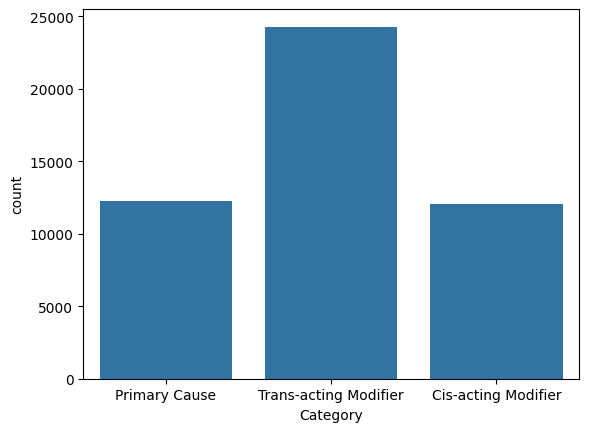

<Figure size 1500x800 with 0 Axes>

In [40]:
import matplotlib.pyplot as plt
sns.countplot(x='Category',data=df)
plt.figure(figsize=(15,8))
plt.show()

<Axes: title={'center': 'Disease stages in Huntington Disease'}, xlabel='Disease_Stage', ylabel='count'>

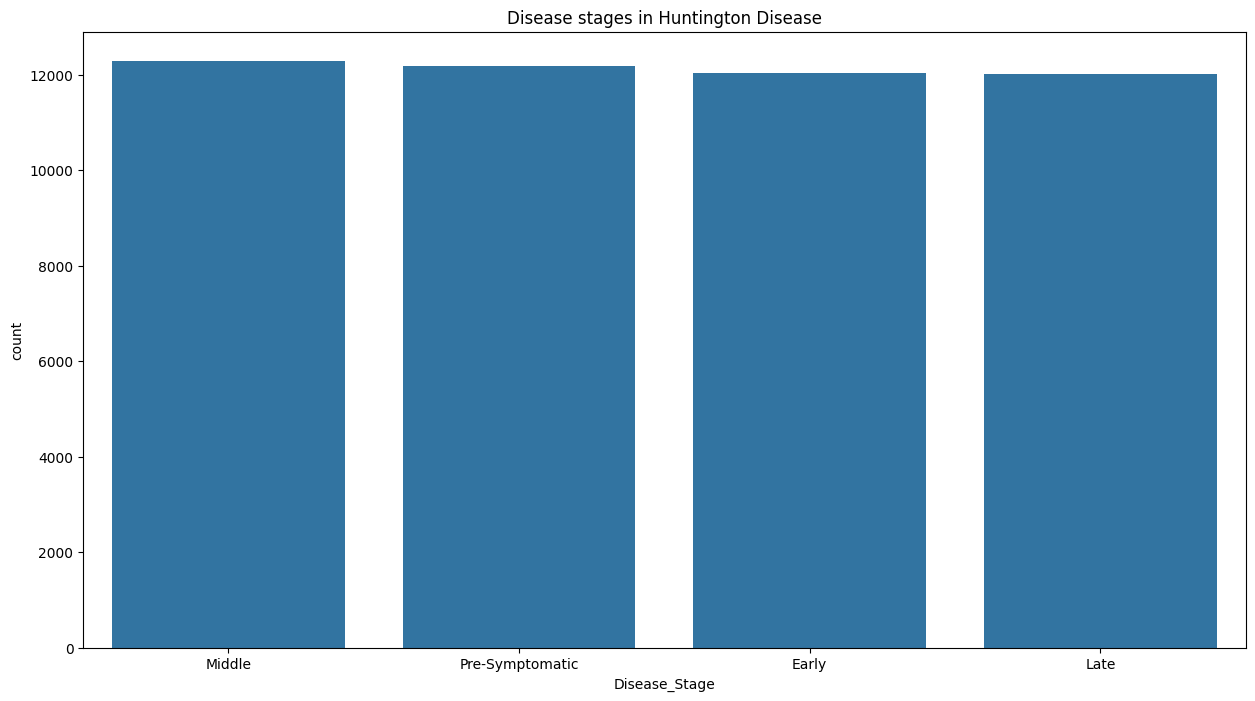

In [41]:
plt.figure(figsize=(15,8))
plt.title("Disease stages in Huntington Disease")
sns.countplot(x='Disease_Stage',data=df)

<Axes: ylabel='count'>

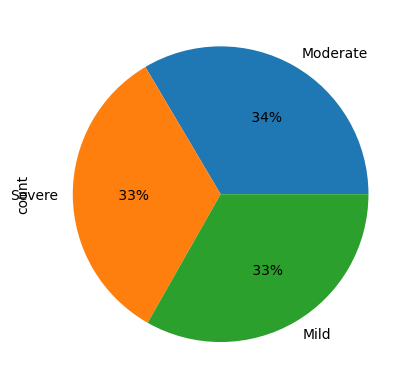

In [42]:
df['Motor_Symptoms'].value_counts().plot.pie(autopct="% 0.f%%")

## Bivariate Analysis

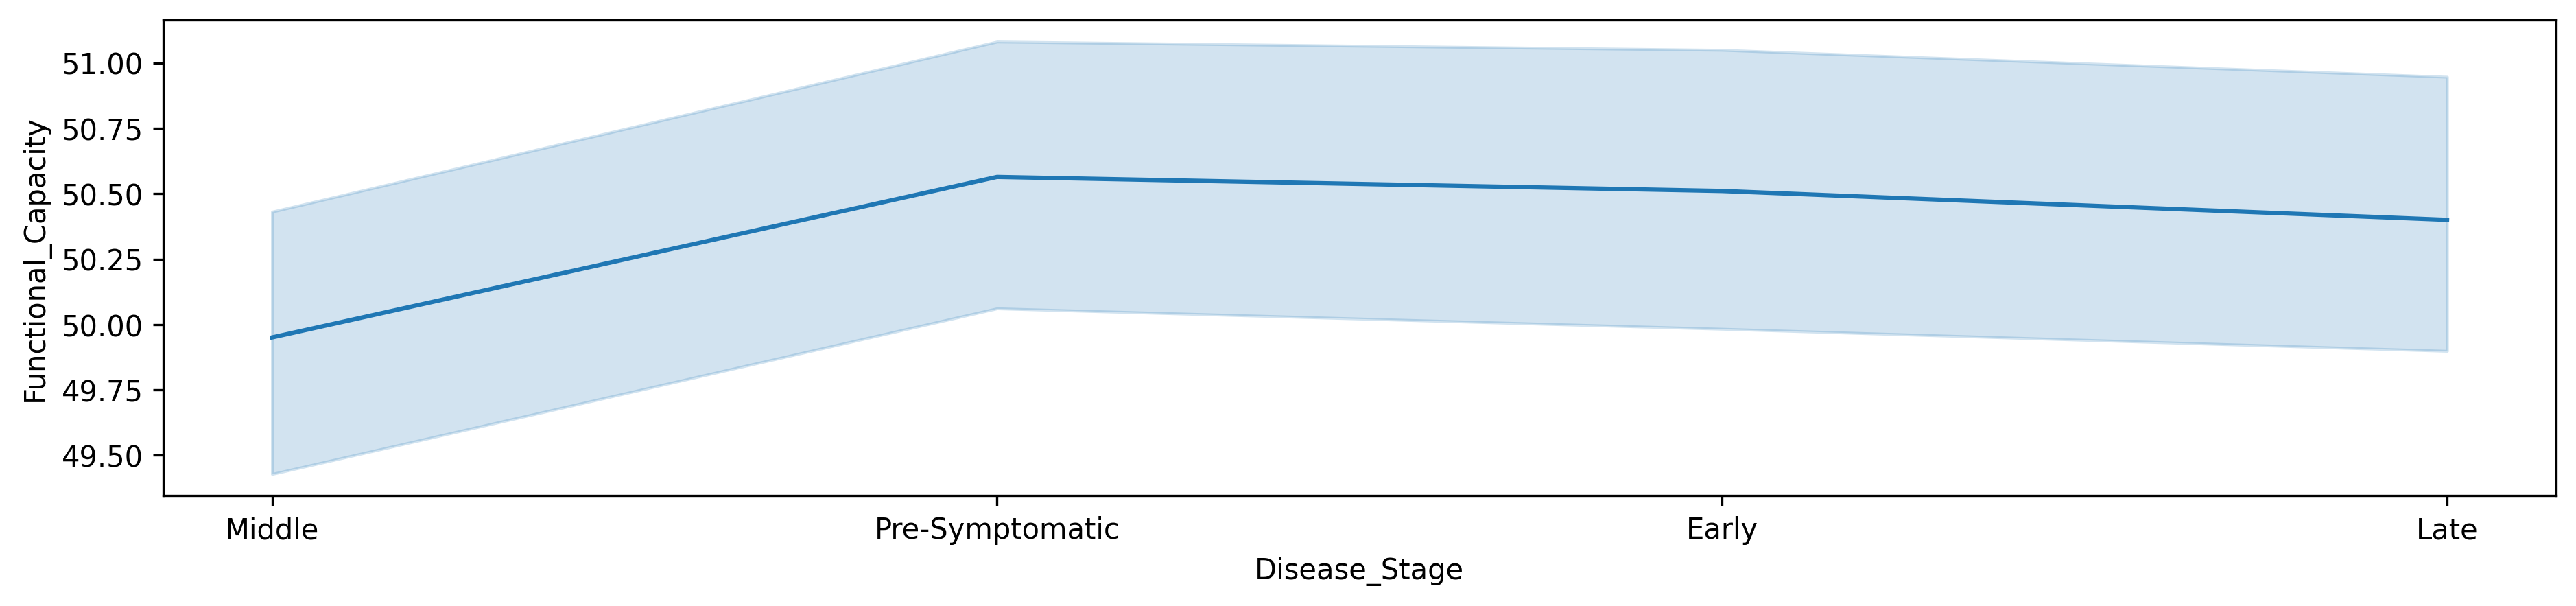

In [43]:
plt.figure(figsize=(15,3), dpi = 300)
sns.lineplot(x = "Disease_Stage", y = "Functional_Capacity", data = df)
plt.show()

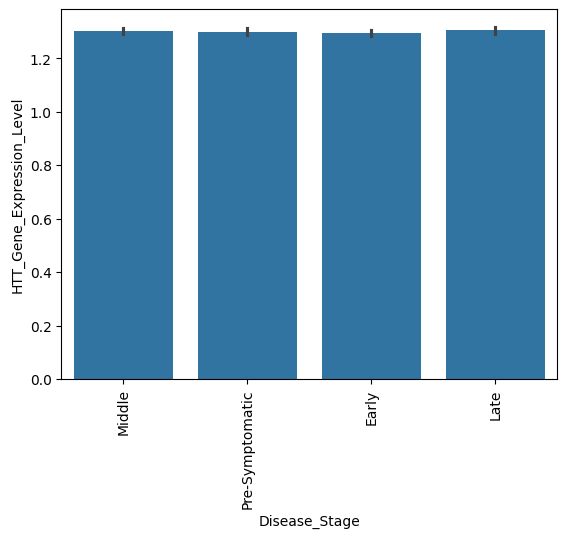

In [44]:
## Bar Graph - Numerical Vs Categorical
sns.barplot(x='Disease_Stage', y='HTT_Gene_Expression_Level', data=df)
plt.xticks(rotation = 90)
plt.show()

## Multivariate Analysis

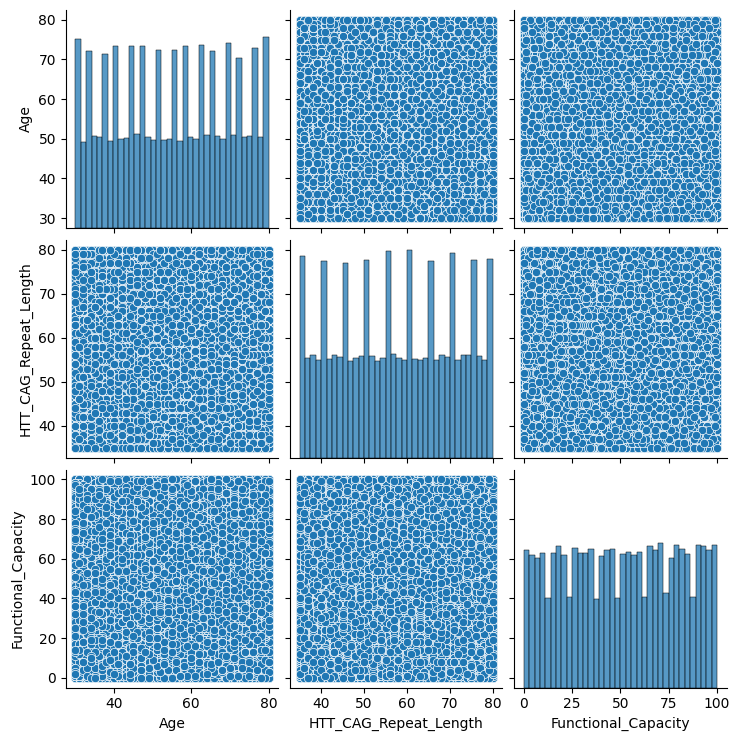

In [45]:
sns.pairplot(data = df, vars=['Age','HTT_CAG_Repeat_Length','Functional_Capacity'])
plt.show()

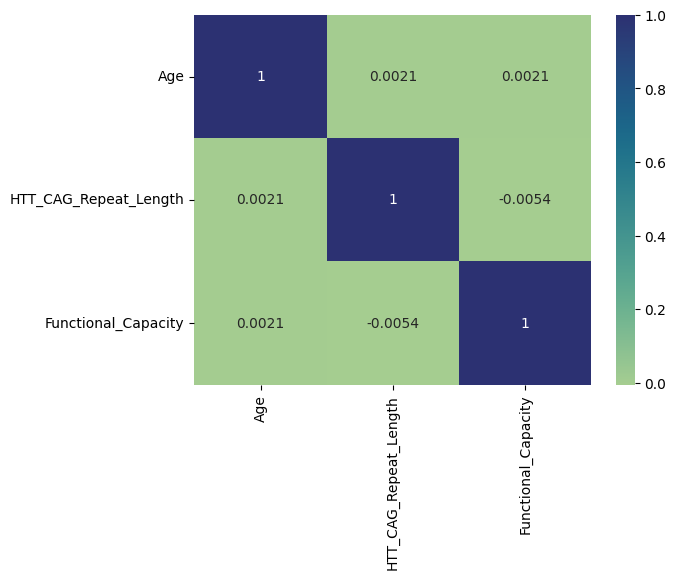

In [46]:
color = sns.color_palette("crest", as_cmap=True)
sns.heatmap(df[['Age','HTT_CAG_Repeat_Length','Functional_Capacity']].corr(), annot=True,cmap=color)
plt.show()

In [47]:
df.drop([
    'Gene/Factor',
    'Disease_Stage'
], axis=1, inplace=True)

In [48]:
# Remove leakage columns
df.drop(['Effect', 'Function'], axis=1, inplace=True)

In [49]:
X = df.drop(columns=['Patient_ID', 'Age', 'Sex', 'Family_History', 'HTT_CAG_Repeat_Length',
       'Motor_Symptoms', 'Cognitive_Decline', 'Chorea_Score',
       'Brain_Volume_Loss', 'Functional_Capacity', 'Gene_Mutation_Type',
       'HTT_Gene_Expression_Level', 'Protein_Aggregation_Level',
       'Random_Protein_Sequence', 'Random_Gene_Sequence',
       'Chromosome_Location'])
y = df['Category']

In [50]:
df.columns

Index(['Patient_ID', 'Age', 'Sex', 'Family_History', 'HTT_CAG_Repeat_Length',
       'Motor_Symptoms', 'Cognitive_Decline', 'Chorea_Score',
       'Brain_Volume_Loss', 'Functional_Capacity', 'Gene_Mutation_Type',
       'HTT_Gene_Expression_Level', 'Protein_Aggregation_Level',
       'Random_Protein_Sequence', 'Random_Gene_Sequence',
       'Chromosome_Location', 'Category'],
      dtype='object')

## Feature Encoding

In [110]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False,drop="first")
ohe.fit_transform(df[['Sex','Family_History','Motor_Symptoms','Cognitive_Decline','Category']])

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 1., 0.],
       ...,
       [0., 0., 1., ..., 0., 1., 0.],
       [1., 1., 0., ..., 0., 0., 1.],
       [1., 1., 1., ..., 0., 0., 1.]], shape=(48536, 9))

In [112]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit_transform(df[['Category']])

array([0, 0, 1, ..., 1, 2, 2], shape=(48536,))

In [51]:
drop_cols = ['CustomerID', 'State', 'Country']

In [52]:
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [53]:
cat_cols = df.select_dtypes(include=['object']).columns

In [54]:
for col in cat_cols:
    
    # Encode only if unique values are small
    if df[col].nunique() < 10:
        df[col] = pd.factorize(df[col])[0]
    
    else:
        # Drop large categorical columns
        df.drop(col, axis=1, inplace=True)

In [55]:
df = pd.get_dummies(df, drop_first=True)

## Feature Scaling

In [115]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df["HTT_Gene_Expression_Level_scaled"] = scaler.fit_transform(df[["HTT_Gene_Expression_Level"]])
df["Age_scaled"] = scaler.fit_transform(df[["Age"]])
df["Functional_Capacity_scaled"] = scaler.fit_transform(df[["Functional_Capacity"]])

In [116]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df["Brain_Volume_Loss_scaled"] = scaler.fit_transform(df[["Brain_Volume_Loss"]])
df["Protein_Aggregation_Level_scaled"] = scaler.fit_transform(df[["Protein_Aggregation_Level"]])

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [59]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((33975, 13), (14561, 13), (33975,), (14561,))

In [60]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [61]:
X_train = scaler.fit_transform(X_train)

In [62]:
X_test = scaler.transform(X_test)

In [63]:
X_train

array([[-1.02770503, -1.00280009,  0.99850002, ...,  1.23735715,
         1.05739335, -0.91061265],
       [ 1.00546336,  0.99720772, -1.00150223, ..., -1.15681243,
        -0.70193215, -0.91061265],
       [-1.56988327, -1.00280009, -1.00150223, ...,  0.81909861,
         0.72531183, -0.91061265],
       ...,
       [ 0.192196  ,  0.99720772,  0.99850002, ...,  1.17966632,
        -1.08347262,  0.29222024],
       [-0.41775452,  0.99720772,  0.99850002, ...,  0.32872653,
        -0.19321152,  1.49505313],
       [-1.02770503,  0.99720772,  0.99850002, ..., -1.17123513,
        -0.2568016 ,  1.49505313]], shape=(33975, 13))

## Logistic Regression

In [64]:
from sklearn.linear_model import LogisticRegression

In [65]:
model = LogisticRegression(max_iter=1000)

In [66]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [67]:
y_pred = model.predict(X_test)

In [68]:
y_pred

array([1, 0, 0, ..., 2, 2, 2], shape=(14561,))

In [69]:
X.columns

Index(['Age', 'Sex', 'Family_History', 'HTT_CAG_Repeat_Length',
       'Motor_Symptoms', 'Cognitive_Decline', 'Chorea_Score',
       'Brain_Volume_Loss', 'Functional_Capacity', 'Gene_Mutation_Type',
       'HTT_Gene_Expression_Level', 'Protein_Aggregation_Level',
       'Chromosome_Location'],
      dtype='object')

In [70]:
y

0        0
1        0
2        1
3        1
4        2
        ..
48531    1
48532    2
48533    1
48534    2
48535    2
Name: Category, Length: 48536, dtype: int64

## Model Evaluation

In [71]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

In [72]:
accuracy_score(y_test,y_pred)

0.7491930499278896

In [73]:
print("Precision :", precision_score(
    y_test,
    y_pred,
    average='weighted'
))

Precision : 0.7492829242192794


In [74]:
print("Recall :", recall_score(
    y_test,
    y_pred,
    average='weighted'
))

Recall : 0.7491930499278896


In [75]:
print("F1 Score :", f1_score(
    y_test,
    y_pred,
    average='weighted'
))

F1 Score : 0.7453696662193561


In [76]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.51      0.63      0.56      3698
           1       1.00      1.00      1.00      7175
           2       0.51      0.38      0.44      3688

    accuracy                           0.75     14561
   macro avg       0.67      0.67      0.67     14561
weighted avg       0.75      0.75      0.75     14561



In [77]:
print(confusion_matrix(y_test,y_pred))

[[2322    0 1376]
 [   0 7175    0]
 [2276    0 1412]]


In [78]:
print(df['Category'].value_counts())

Category
1    24279
0    12229
2    12028
Name: count, dtype: int64


## Overfitting & Underfitting check

In [117]:
train_score = model.score(X_train, y_train)
train_score

0.7589698307579102

In [118]:
test_score = model.score(X_test, y_test)
test_score

0.7491930499278896

In [83]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print(scores)
print("Mean Accuracy :", scores.mean())

[0.75401731 0.7519316  0.75059236 0.75450706 0.74997425]
Mean Accuracy : 0.7522045118511318


In [84]:
# Correlation matrix
corr = df.corr(numeric_only=True)

# Correlation with target column
print(corr['Category'].sort_values(ascending=False))

Category                     1.000000
Functional_Capacity          0.009462
Family_History               0.007272
Chorea_Score                 0.006654
Chromosome_Location          0.005303
Protein_Aggregation_Level    0.004510
HTT_CAG_Repeat_Length        0.003098
HTT_Gene_Expression_Level   -0.000098
Age                         -0.000995
Gene_Mutation_Type          -0.001109
Sex                         -0.001136
Brain_Volume_Loss           -0.003242
Motor_Symptoms              -0.007086
Cognitive_Decline           -0.007331
Name: Category, dtype: float64


## Cross Validation 

In [85]:
from sklearn.model_selection import cross_val_score

In [86]:
cv_score = cross_val_score(
    estimator=model,
    X=X,
    y=y,
    cv=5,
    n_jobs=4,
    verbose=2
)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 out of   5 | elapsed:   27.3s finished


In [88]:
cv_score

array([0.75185414, 0.75110745, 0.7519316 , 0.75522819, 0.75018028])

## Hyperparameter Tuning

In [89]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    #'solver': ['liblinear']
}

In [90]:
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

In [91]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : t

In [92]:
grid.best_params_

{'C': 10, 'penalty': 'l2'}

In [93]:
grid.best_score_

np.float64(0.7547019867549668)

In [94]:
final_model = grid.best_estimator_

In [95]:
final_y_pred = final_model.predict(X_test)
final_y_pred

array([1, 0, 0, ..., 2, 2, 2], shape=(14561,))

In [96]:
accuracy_score(y_test, final_y_pred)

0.7491243733260078

## RandomSearch CV

In [97]:
from sklearn.model_selection import RandomizedSearchCV
rand_cv = RandomizedSearchCV(estimator = model, param_distributions = param_grid,n_iter=20,scoring="accuracy",n_jobs=-1,cv=5,verbose=2)

In [98]:
rand_cv.fit(X_train,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-f

In [99]:
rand_cv.best_params_

{'penalty': 'l2', 'C': 10}

In [100]:
rand_cv.best_score_

np.float64(0.7547019867549668)

In [103]:
final_rand_cv = rand_cv.best_estimator_

In [104]:
rand_y_pred = final_rand_cv.predict(X_test)
rand_y_pred

array([1, 0, 0, ..., 2, 2, 2], shape=(14561,))

In [105]:
accuracy_score(rand_y_pred, y_test)

0.7491243733260078

## Build Final Model

In [106]:
best_model = LogisticRegression(
    C=1,
    penalty='l2',
    solver='lbfgs',
    max_iter=5000
)

best_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` p

## Final Evaluation

In [107]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred,average='weighted'))
print("Recall   :", recall_score(y_test,y_pred,average='weighted'))
print("F1 Score :", f1_score(y_test,y_pred,average='weighted'))

print(classification_report(y_test,y_pred))

Accuracy : 0.7491930499278896
Precision: 0.7492829242192794
Recall   : 0.7491930499278896
F1 Score : 0.7453696662193561
              precision    recall  f1-score   support

           0       0.51      0.63      0.56      3698
           1       1.00      1.00      1.00      7175
           2       0.51      0.38      0.44      3688

    accuracy                           0.75     14561
   macro avg       0.67      0.67      0.67     14561
weighted avg       0.75      0.75      0.75     14561



In [108]:
train_acc = best_model.score(X_train,y_train)
test_acc = best_model.score(X_test,y_test)

print("Train Accuracy:",train_acc)
print("Test Accuracy :",test_acc)

Train Accuracy: 0.7589698307579102
Test Accuracy : 0.7491930499278896


## Model Serialization

In [109]:
import pickle

with open("final_model.pkl","wb") as file:
    pickle.dump(best_model,file)

print("Model Saved Successfully")

Model Saved Successfully


## Conclusion
* Among the evaluated machine learning models, Logistic Regression and Gaussian Naive Bayes achieved similar performance with a training accuracy of 0.75 and testing accuracy of 0.74. Additional evaluation metrics such as Precision, Recall, and F1-Score also showed comparable results. Logistic Regression was selected as the final model because it provides better interpretability, handles correlated features effectively, and is widely accepted as a strong baseline classifier for healthcare and disease prediction applications. Furthermore, the model demonstrated good generalization with a minimal gap between training and testing performance, indicating the absence of significant overfitting.